In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
# Parse dates and set date column to index
df = pd.read_csv("data/btc1h_usdt.csv", 
                 parse_dates=["open_time"], 
                 index_col=["open_time"]) # parse the date column (tell pandas column 1 is a datetime)
#Sorting the data based on Increasing value of date
df.sort_values(by='open_time',ascending=True, inplace = True)
df.head()
df.tail()



,Unnamed: 0,open,high,low,close,volume,close_time,quote_vol,trades,taker_buy_base,...,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,sma200,sma50,ema200,ema50,slope,slope_obv,slope_rsi
open_time,,,,,,,,,,,,,,,,,,,,,
2025-01-09 13:00:00,64725,93421.94,93486.19,91900.12,92113.06,3356.62241,2025-01-09 13:59:59.999,3.103351e+08,348237.0,1256.86418,...,NaN,NaN,NaN,97273.08590,95605.9272,96902.623310,95507.199053,-102.948968,-615.768747,-0.838106
2025-01-09 14:00:00,64726,91986.41,92786.54,91800.00,92786.54,2300.48467,2025-01-09 14:59:59.999,2.123335e+08,373009.0,1108.75649,...,NaN,NaN,NaN,97268.32430,95446.9710,96861.667257,95400.506541,-105.304683,-585.623974,-0.422068
2025-01-09 15:00:00,64727,92863.81,94588.23,92671.67,94363.64,2478.34893,2025-01-09 15:59:59.999,2.320427e+08,350503.0,1350.80201,...,NaN,NaN,NaN,97271.72195,95321.2208,96836.811265,95359.845108,-102.499874,-338.764423,0.807167
2025-01-09 16:00:00,64728,94244.02,94685.25,93846.15,94230.62,1572.89161,2025-01-09 16:59:59.999,1.482196e+08,256347.0,666.46850,...,NaN,NaN,NaN,97275.66650,95206.1168,96810.879013,95315.561771,-95.932735,-179.430363,1.665067
2025-01-09 17:00:00,64729,94250.96,94293.96,92325.00,92795.16,1851.18100,2025-01-09 17:59:59.999,1.724752e+08,376721.0,780.35803,...,NaN,NaN,NaN,97272.63165,95101.7164,96770.921610,95216.722486,-91.207137,8.423442,1.456560


In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load data
df = pd.read_csv('data/btc1h_usdt.csv')

# Features to use for clustering and prediction
features_for_clustering = [
    'open', 'high', 'low', 'close', 'volume',
    'sma200', 'sma50', 'ema200', 'ema50', 'slope_rsi'
]

# Display initial shape
print("Original shape:", df.shape)

# Drop rows with NaNs only in the relevant features (preserve others if needed)
df = df.dropna(subset=features_for_clustering)

# Display shape after drop
print("Shape after dropping NaNs in selected features:", df.shape)

# Normalize selected features using Min-Max scaling
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[features_for_clustering])

# Create DataFrame with scaled values
df_scaled = pd.DataFrame(scaled_features, columns=features_for_clustering)

# Optional: merge back the scaled features into the original df if needed
df_scaled.index = df.index  # retain alignment
df_combined = df.copy()
df_combined[features_for_clustering] = df_scaled

# Preview the final dataframe
print(df_combined.head())


Original shape: (64730, 112)
Shape after dropping NaNs in selected features: (64531, 112)
     Unnamed: 0                open_time      open      high       low  \
199         199  2017-08-25 11:00:00.000  0.013861  0.013389  0.014341   
200         200  2017-08-25 12:00:00.000  0.014142  0.013389  0.013844   
201         201  2017-08-25 13:00:00.000  0.013671  0.013235  0.014194   
202         202  2017-08-25 14:00:00.000  0.013597  0.013187  0.014136   
203         203  2017-08-25 15:00:00.000  0.013764  0.013968  0.014423   

        close    volume               close_time      quote_vol  trades  ...  \
199  0.013702  0.000184  2017-08-25 11:59:59.999  111811.088940   216.0  ...   
200  0.013212  0.000805  2017-08-25 12:59:59.999  479266.243589  1891.0  ...   
201  0.013234  0.000148  2017-08-25 13:59:59.999   89785.160922   188.0  ...   
202  0.013168  0.000073  2017-08-25 14:59:59.999   45804.268023   139.0  ...   
203  0.014017  0.000155  2017-08-25 15:59:59.999   95349.335161  

In [3]:
 df_combined.describe()

,Unnamed: 0,open,high,low,close,volume,quote_vol,trades,taker_buy_base,taker_buy_quote,...,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,sma200,sma50,ema200,ema50,slope,slope_obv,slope_rsi
count,64531.000000,64531.000000,64531.000000,64531.000000,64531.000000,64531.000000,6.453100e+04,6.453100e+04,64531.000000,6.453100e+04,...,5460.000000,5460.000000,5460.000000,64531.000000,64531.000000,64531.000000,64531.000000,64531.000000,64531.000000,64531.000000
mean,32464.000000,0.232097,0.232514,0.233723,0.231938,0.020700,7.174521e+07,6.767997e+04,1412.325222,3.553637e+07,...,-1.316515,-1.263226,-0.053289,0.240012,0.234102,0.239424,0.234523,1.415603,-0.217109,0.505787
std,18628.639448,0.212220,0.213044,0.213501,0.212493,0.029927,1.038136e+08,9.819208e+04,2044.477246,5.174812e+07,...,11.453303,9.087468,6.228195,0.223301,0.217111,0.222694,0.217612,30.272327,2347.461747,0.102428
min,199.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.345722e+03,5.000000e+00,0.004000,1.470000e+01,...,-38.612434,-35.513034,-17.093415,0.000000,0.000000,0.000000,0.000000,-273.849811,-168701.413019,0.000000
25%,16331.500000,0.054337,0.054084,0.054817,0.053967,0.006469,1.178079e+07,1.361900e+04,444.510604,5.926092e+06,...,-8.908642,-7.119905,-4.188456,0.052234,0.052105,0.052268,0.052005,-6.517255,-404.540449,0.442340
50%,32464.000000,0.165961,0.166029,0.167348,0.165718,0.011393,3.482959e+07,3.381500e+04,782.466654,1.683564e+07,...,-2.332870,-1.788624,-0.857378,0.171955,0.166866,0.170869,0.167203,0.590277,4.120874,0.506714
75%,48596.500000,0.373508,0.374392,0.376280,0.373513,0.021977,9.245265e+07,7.531450e+04,1501.065333,4.557785e+07,...,4.901889,3.950645,3.006291,0.391543,0.379753,0.390720,0.380869,9.302993,407.210600,0.570292
max,64729.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.005634e+09,1.442097e+06,68611.450390,1.502977e+09,...,55.889468,35.430883,37.331097,1.000000,1.000000,1.000000,1.000000,256.407975,34401.591923,1.000000


In [20]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Replace inf/-inf with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Convert all applicable columns to numeric (coerce errors)
df = df.apply(pd.to_numeric, errors='coerce')

# Fill NaNs with column mean
df.fillna(df.mean(), inplace=True)

# Columns to scale
columns_to_scale = ["slope_rsi", "momentum_pvo", "momentum_pvo_signal", "momentum_pvo_hist"]
valid_columns = [col for col in columns_to_scale if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]

# Standard scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[valid_columns])

# Optional: put scaled data back into a DataFrame for visualization
scaled_df = pd.DataFrame(scaled_data, columns=valid_columns)

# Show first few rows
display(scaled_df.head())


,slope_rsi,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist
0,-0.176249,0.0,0.0,3.830502e-18
1,-0.046505,0.0,0.0,3.830502e-18
2,-0.170587,0.0,0.0,3.830502e-18
3,-0.307180,0.0,0.0,3.830502e-18
4,-0.213144,0.0,0.0,3.830502e-18


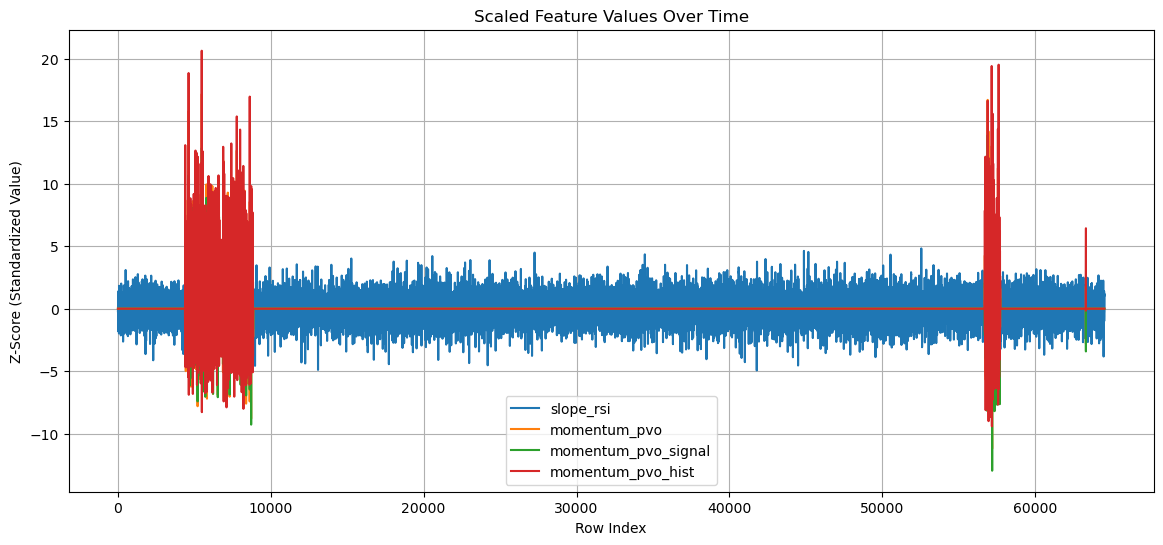

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
for col in valid_columns:
    plt.plot(scaled_df[col], label=col)

plt.title('Scaled Feature Values Over Time')
plt.xlabel('Row Index')
plt.ylabel('Z-Score (Standardized Value)')
plt.legend()
plt.grid(True)
plt.show()


In [29]:
from sklearn.cluster import KMeans
print(scaled_df.shape)
print(scaled_df.head())
print(valid_columns)
print("Scaled df shape:", scaled_df.shape)
print("Valid columns:", valid_columns)
print(scaled_df.head())
data_for_clustering = scaled_df[valid_columns]
print(data_for_clustering.shape)

from sklearn.cluster import KMeans

# Check if data is not empty
data_for_clustering = scaled_df[valid_columns]

if data_for_clustering.shape[0] == 0:
    print("Error: No data available for clustering. Check your preprocessing steps.")
else:
    k = 3
    kmeans = KMeans(n_clusters=k, random_state=42)
    df['regime'] = kmeans.fit_predict(data_for_clustering)



(0, 4)
Empty DataFrame
Columns: [slope_rsi, momentum_pvo, momentum_pvo_signal, momentum_pvo_hist]
Index: []
['slope_rsi', 'momentum_pvo', 'momentum_pvo_signal', 'momentum_pvo_hist']
Scaled df shape: (0, 4)
Valid columns: ['slope_rsi', 'momentum_pvo', 'momentum_pvo_signal', 'momentum_pvo_hist']
Empty DataFrame
Columns: [slope_rsi, momentum_pvo, momentum_pvo_signal, momentum_pvo_hist]
Index: []
(0, 4)
Error: No data available for clustering. Check your preprocessing steps.


In [31]:
models = {}
for regime in df['regime'].unique():
    idx = df['regime'] == regime
    X_regime = scaled_df[idx]
    y_regime = df.loc[idx, 'target']  # target shifted price
    
    # Split, train model per regime
    # ...
    model = LinearRegression().fit(X_train, y_train)
    models[regime] = model


KeyError: 'regime'